# ANÁLISIS EXPLORATORIO DE DATOS (EDA) — BANCO ATLAS
- Base de datos: BANK_marketing (importada desde MySQL)
- Fecha: Mayo 2026
- Equipo: Equipo 27
### OBJETIVO DEL EDA:
Preparar la base de datos para que los 3 departamentos puedan responder las preguntas del Desafío 3:
1. PERFIL DEL CLIENTE: ¿Qué combinaciones demográficas son comunes entre clientes multi-producto?
2. MARKETING Y COMUNICACIÓN: ¿Cómo influyen los días de la semana en la efectividad de las campañas?
3. FINANZAS Y RIESGO CREDITICIO: ¿Qué umbrales de saldo indican mayor riesgo de morosidad?

###  INSTALACIÓN DE DEPENDENCIAS
- PyMySQL: conector para MySQL desde Python
- cryptography: requerido por PyMySQL para conexiones seguras
- mysql-connector-python: conector alternativo (backup)

In [1]:
! pip install PyMySQL
! pip install cryptography
! pip install mysql-connector-python

###  IMPORTACIÓN DE LIBRERÍAS

In [2]:
# Conexión a bases de datos
import pymysql
import warnings

In [3]:
# Manipulación de datos
import pandas as pd
import numpy as np

In [4]:
# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')  
sns.set_palette("husl")                

In [7]:
# Configuración de pandas para visualización completa
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.max_rows', 100)      # Mostrar hasta 100 filas
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimales

### CONEXIÓN A LA BASE DE DATOS Y CARGA DE DATOS

In [8]:
connection = pymysql.connect(
    host="212.227.90.6",        # Servidor remoto
    user="Equipo27",             # Usuario del equipo
    password="E1q2u3i4p5o27",    # Contraseña asignada
    database="Equip_27",         # Base de datos del equipo
    port=3306                    # Puerto estándar de MySQL
)

tablas = pd.read_sql("SHOW TABLES", connection).iloc[:, 0].tolist()

dfs = {}
for tabla in tablas:
    dfs[tabla] = pd.read_sql(f"SELECT * FROM {tabla}", connection)

df = dfs['BANK_marketing'].copy()

connection.close()

C:\Users\Margot\AppData\Local\Temp\ipykernel_18412\575780919.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tablas = pd.read_sql("SHOW TABLES", connection).iloc[:, 0].tolist()
C:\Users\Margot\AppData\Local\Temp\ipykernel_18412\575780919.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dfs[tabla] = pd.read_sql(f"SELECT * FROM {tabla}", connection)


### 1. EXPLORACIÓN GENERAL DEL DATASET

In [9]:
print("="*60)
print("RESUMEN DEL DATASET")
print("="*60)

# 4.1. Dimensiones
print(f"\n DIMENSIONES:")
print(f"  • Número de filas (clientes): {df.shape[0]:,}")
print(f"  • Número de columnas (variables): {df.shape[1]}")

# 4.2. Primeras filas
print(f"\n PRIMERAS 5 FILAS:")
display(df.head())

# 4.3. Información de tipos de datos y valores no nulos
print(f"\n INFORMACIÓN DE TIPOS Y VALORES NO NULOS:")
df.info()

# 4.4. Resumen estadístico de variables numéricas
print(f"\n ESTADÍSTICAS DESCRIPTIVAS (NUMÉRICAS):")
display(df.describe())

# 4.5. Resumen estadístico de variables categóricas
print(f"\n ESTADÍSTICAS DESCRIPTIVAS (CATEGÓRICAS):")
display(df.describe(include='object'))

RESUMEN DEL DATASET

 DIMENSIONES:
  • Número de filas (clientes): 11,162
  • Número de columnas (variables): 18

 PRIMERAS 5 FILAS:


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.00,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,2,56.00,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,3,41.00,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,4,55.00,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,5,54.00,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes



 INFORMACIÓN DE TIPOS Y VALORES NO NULOS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         11162 non-null  int64  
 1   age        11152 non-null  float64
 2   job        11162 non-null  object 
 3   marital    11157 non-null  object 
 4   education  11155 non-null  object 
 5   default    11162 non-null  object 
 6   balance    11162 non-null  int64  
 7   housing    11162 non-null  object 
 8   loan       11162 non-null  object 
 9   contact    11162 non-null  object 
 10  day        11162 non-null  int64  
 11  month      11162 non-null  object 
 12  duration   11162 non-null  int64  
 13  campaign   11162 non-null  int64  
 14  pdays      11162 non-null  int64  
 15  previous   11162 non-null  int64  
 16  poutcome   11162 non-null  object 
 17  deposit    11162 non-null  object 
dtypes: float64(1), int64(7), object(10)
memory 

,id,age,balance,day,duration,campaign,pdays,previous
count,11162.00,11152.00,11162.00,11162.00,11162.00,11162.00,11162.00,11162.00
mean,5581.50,41.24,1528.54,15.66,371.99,2.51,51.33,0.83
std,3222.34,11.91,3225.41,8.42,347.13,2.72,108.76,2.29
min,1.00,18.00,-6847.00,1.00,2.00,1.00,-1.00,0.00
25%,2791.25,32.00,122.00,8.00,138.00,1.00,-1.00,0.00
50%,5581.50,39.00,550.00,15.00,255.00,2.00,-1.00,0.00
75%,8371.75,49.00,1708.00,22.00,496.00,3.00,20.75,1.00
max,11162.00,95.00,81204.00,31.00,3881.00,63.00,854.00,58.00



 ESTADÍSTICAS DESCRIPTIVAS (CATEGÓRICAS):


,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,11162,11157,11155,11162,11162,11162,11162,11162,11162,11162
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2566,6349,5474,10994,5881,9702,8042,2824,8326,5873


El dataset cuenta con 11,162 registros y 18 variables. Es un conjunto de datos mixto que combina información demográfica (edad, trabajo, educación), financiera (saldo, préstamos, morosidad) y de contacto de campañas previas. La variable objetivo es deposit, que indica si el cliente contrató un depósito a plazo.

Conclusión:
- Se dispone de una base de datos robusta y de tamaño suficiente para realizar inferencias estadísticas.
- La presencia de una columna id única permite la trazabilidad individual de los clientes sin ambigüedades.

### 2. ANÁLISIS DE CALIDAD DE DATOS

In [10]:
# Ver datos faltantes
missing_values = df.isnull().sum() | df.isna().sum()

In [11]:
# Porcentaje de valores faltantes
missing_percentage = (missing_values / len(df)) * 100
missing_data = pd.DataFrame({'missing_values': missing_values, 'percentage': missing_percentage})

# solo columnas con datos faltantes
missing_data = missing_data[missing_data['missing_values'] > 0]

missing_data

,missing_values,percentage
age,10,0.09
marital,5,0.04
education,7,0.06


In [17]:
#Identificar filas duplicadas completas
duplicados = df.duplicated().sum()
print(f"Total de registros duplicados: {duplicados}")
print(f"Porcentaje de duplicados: {(duplicados / len(df)) * 100:.2f}%")

Total de registros duplicados: 0
Porcentaje de duplicados: 0.00%



 VALORES FALTANTES DETECTADOS:


,Columna,Valores_faltantes,Porcentaje
0,age,10,0.09
1,education,7,0.06
2,marital,5,0.04


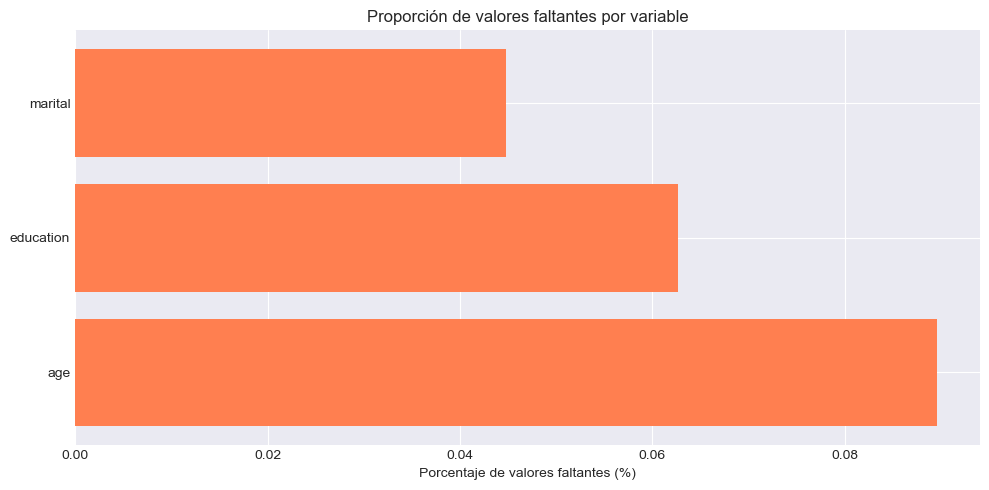

In [18]:
# 1. Identificar valores nulos por columna
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

# Crear DataFrame resumen de valores faltantes
missing_summary = pd.DataFrame({
    'Columna': missing_values.index,
    'Valores_faltantes': missing_values.values,
    'Porcentaje': missing_percentage.values
}).sort_values('Valores_faltantes', ascending=False)

# Mostrar solo columnas con valores faltantes
missing_summary_filtered = missing_summary[missing_summary['Valores_faltantes'] > 0]

if missing_summary_filtered.empty:
    print("\n✓ No se detectaron valores faltantes en ninguna columna.")
else:
    print(f"\n VALORES FALTANTES DETECTADOS:")
    display(missing_summary_filtered.reset_index(drop=True))
    
    # Visualización de valores faltantes
    plt.figure(figsize=(10, 5))
    plt.barh(missing_summary_filtered['Columna'], 
             missing_summary_filtered['Porcentaje'],
             color='coral')
    plt.xlabel('Porcentaje de valores faltantes (%)')
    plt.title('Proporción de valores faltantes por variable')
    plt.tight_layout()
    plt.show()

In [19]:
# 2. Identificar filas duplicadas completas
duplicados = df.duplicated().sum()
print(f"\n DUPLICADOS:")
print(f"  • Filas duplicadas completas: {duplicados}")
if duplicados > 0:
    print(f"  • Porcentaje de duplicados: {(duplicados/len(df))*100:.2f}%")


 DUPLICADOS:
  • Filas duplicadas completas: 0


In [20]:
# 5.3. Identificar duplicados en la columna 'id' (debe ser única)
if 'id' in df.columns:
    duplicados_id = df['id'].duplicated().sum()
    print(f"  • IDs duplicados: {duplicados_id}")
    if duplicados_id > 0:
        print(f"    ADVERTENCIA: La columna 'id' tiene duplicados. Revisar integridad.")

  • IDs duplicados: 0


- Valores Faltantes: Se detectó una cantidad mínima de datos nulos en age (0.09%), education (0.06%) y marital (0.04%).  
- Duplicados: No existen filas duplicadas en el dataset ni registros repetidos en la columna id.  
- Integridad: Variables como pdays muestran valores de -1, lo cual no es un error, sino una codificación que indica que el cliente no fue contactado previamente.
##### Conclusión:
La calidad del dataset es buena; los valores faltantes representan menos del 0.1% de la muestra, por lo que su impacto en el análisis no puede sesgar los resultados.

### ANÁLISIS VARIABLES NUMÉRICAS

In [21]:
# 1. Seleccionar variables numéricas (excluyendo 'id')
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'id' in numeric_cols:
    numeric_cols.remove('id')  # 'id' no es una variable de análisis

print(f"\n Variables numéricas a analizar: {numeric_cols}")


 Variables numéricas a analizar: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [22]:
# 6.3. Calcular estadísticos personalizados (media, mediana, moda, desviación)
stats_summary = pd.DataFrame({
    'Variable': numeric_cols,
    'Media': [df[col].mean() for col in numeric_cols],
    'Mediana': [df[col].median() for col in numeric_cols],
    'Moda': [df[col].mode()[0] if not df[col].mode().empty else np.nan for col in numeric_cols],
    'Desv_std': [df[col].std() for col in numeric_cols],
    'Min': [df[col].min() for col in numeric_cols],
    'Max': [df[col].max() for col in numeric_cols],
    'Rango': [df[col].max() - df[col].min() for col in numeric_cols]
})

print(f"\n RESUMEN ESTADÍSTICO:")
display(stats_summary)


 RESUMEN ESTADÍSTICO:


,Variable,Media,Mediana,Moda,Desv_std,Min,Max,Rango
0,age,41.24,39.00,31.00,11.91,18.00,95.00,77.00
1,balance,1528.54,550.00,0.00,3225.41,-6847.00,81204.00,88051.00
2,day,15.66,15.00,20.00,8.42,1.00,31.00,30.00
3,duration,371.99,255.00,97.00,347.13,2.00,3881.00,3879.00
4,campaign,2.51,2.00,1.00,2.72,1.00,63.00,62.00
5,pdays,51.33,-1.00,-1.00,108.76,-1.00,854.00,855.00
6,previous,0.83,0.00,0.00,2.29,0.00,58.00,58.00


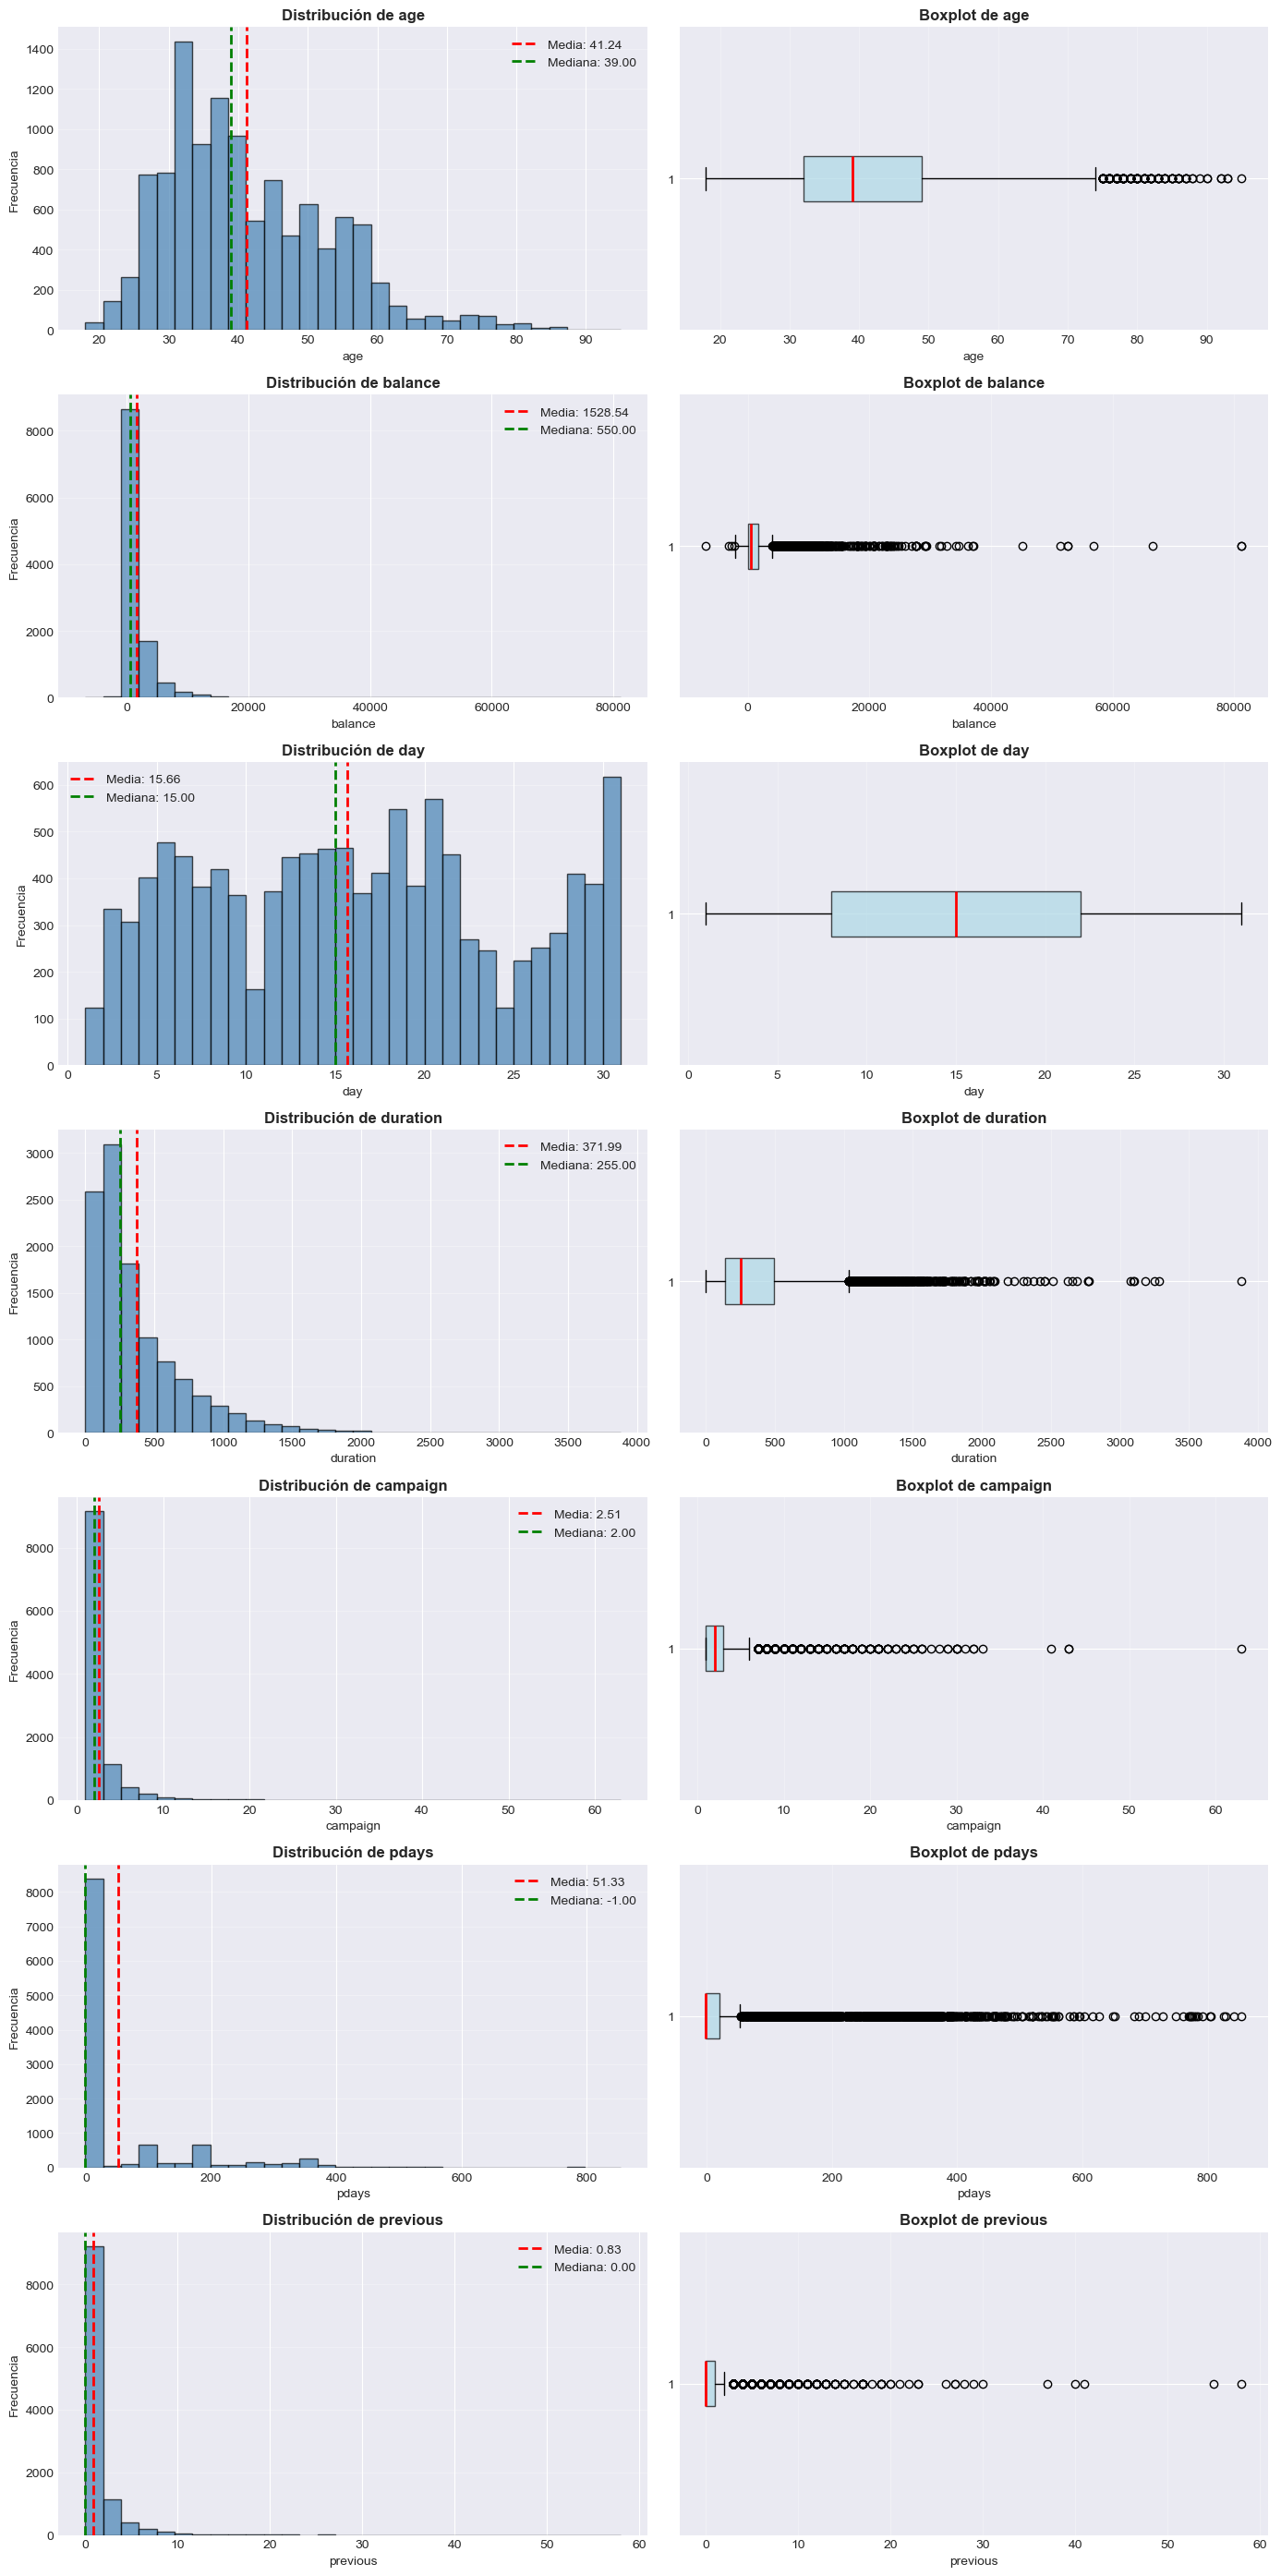

In [23]:
# 3. Visualización de distribuciones: histogramas + boxplots
fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=2, figsize=(14, 4*len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    # Histograma con KDE (distribución suavizada)
    axes[i, 0].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i, 0].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df[col].mean():.2f}')
    axes[i, 0].axvline(df[col].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {df[col].median():.2f}')
    axes[i, 0].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frecuencia')
    axes[i, 0].legend()
    axes[i, 0].grid(axis='y', alpha=0.3)
    
    # Boxplot (detectar outliers)
    axes[i, 1].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', alpha=0.7),
                       medianprops=dict(color='red', linewidth=2))
    axes[i, 1].set_title(f'Boxplot de {col}', fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# 4. Detección de outliers (método IQR — Rango Intercuartílico)
print(f"\n DETECCIÓN DE OUTLIERS (Método IQR):")

outliers_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    n_outliers = len(outliers)
    pct_outliers = (n_outliers / len(df)) * 100
    
    outliers_summary.append({
        'Variable': col,
        'N_outliers': n_outliers,
        'Porcentaje': pct_outliers,
        'Límite_inferior': lower_bound,
        'Límite_superior': upper_bound
    })

outliers_df = pd.DataFrame(outliers_summary).sort_values('N_outliers', ascending=False)
display(outliers_df)


 DETECCIÓN DE OUTLIERS (Método IQR):


,Variable,N_outliers,Porcentaje,Límite_inferior,Límite_superior
5,pdays,2750,24.64,-33.62,53.38
6,previous,1258,11.27,-1.50,2.50
1,balance,1055,9.45,-2257.00,4087.00
3,duration,636,5.70,-399.00,1033.00
4,campaign,601,5.38,-2.00,6.00
0,age,171,1.53,6.50,74.50
2,day,0,0.00,-13.00,43.00


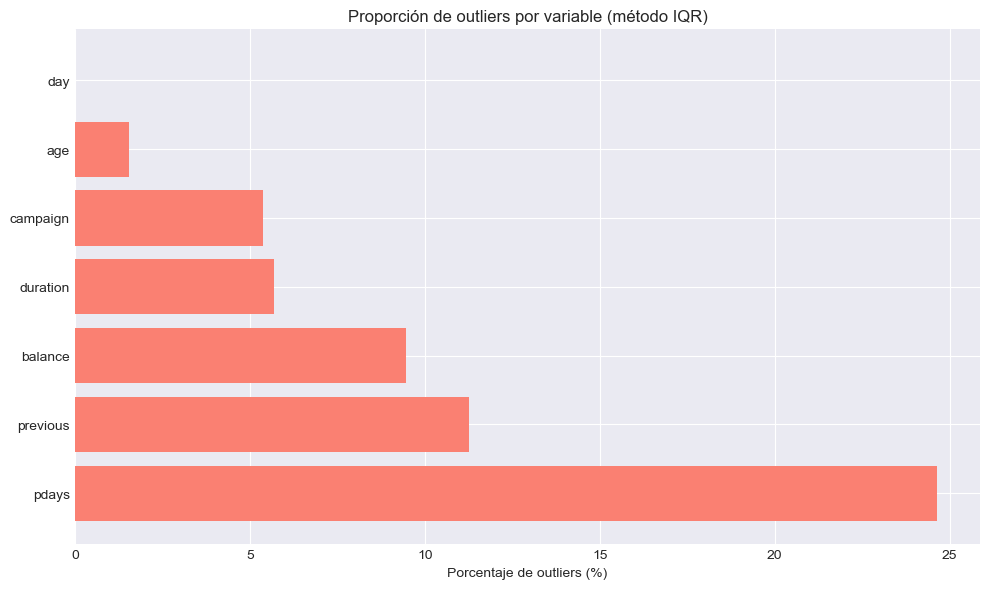

In [25]:
# Visualización de outliers por variable
plt.figure(figsize=(10, 6))
plt.barh(outliers_df['Variable'], outliers_df['Porcentaje'], color='salmon')
plt.xlabel('Porcentaje de outliers (%)')
plt.title('Proporción de outliers por variable (método IQR)')
plt.tight_layout()
plt.show()

- Edad (age): El promedio es de 41 años, con un rango amplio que va desde los 18 hasta los 95 años.  
- Saldo (balance): Existe una alta variabilidad (desviación estándar de 3,225.41). Se observan saldos negativos (mínimo de -6,847) y saldos muy elevados (máximo de 81,204), lo que sugiere la presencia de valores atípicos (outliers).  
- Comportamiento de Campaña: La mediana de contactos por campaña es de 2, pero algunos clientes recibieron hasta 63 contactos.  

Conclusión:
- La distribución del saldo está fuertemente sesgada a la derecha por clientes con altos capitales.
- Es necesario segmentar por rangos de edad y saldo para que los departamentos de Riesgo y Marketing puedan diseñar estrategias diferenciadas.

### ANÁLISIS VARIABLES CATEGÓRICAS

In [26]:
# 1. Seleccionar variables categóricas (tipo 'object')
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome',
 'deposit']

In [27]:
# 2. Resumen de frecuencias y cardinalidad
cat_summary = []

for col in categorical_cols:
    cat_summary.append({
        'Variable': col,
        'Categorías_únicas': df[col].nunique(),
        'Moda': df[col].mode()[0] if not df[col].mode().empty else 'N/A',
        'Frecuencia_moda': df[col].value_counts().iloc[0],
        'Porcentaje_moda': (df[col].value_counts().iloc[0] / len(df)) * 100
    })

cat_summary_df = pd.DataFrame(cat_summary)
print(f"\n RESUMEN DE VARIABLES CATEGÓRICAS:")
display(cat_summary_df)


 RESUMEN DE VARIABLES CATEGÓRICAS:


,Variable,Categorías_únicas,Moda,Frecuencia_moda,Porcentaje_moda
0,job,12,management,2566,22.99
1,marital,3,married,6349,56.88
2,education,4,secondary,5474,49.04
3,default,2,no,10994,98.49
4,housing,2,no,5881,52.69
5,loan,2,no,9702,86.92
6,contact,3,cellular,8042,72.05
7,month,12,may,2824,25.30
8,poutcome,4,unknown,8326,74.59
9,deposit,2,no,5873,52.62



 TABLA DE FRECUENCIAS: JOB


,Categoría,Frecuencia,Porcentaje
0,management,2566,22.99
1,blue-collar,1944,17.42
2,technician,1823,16.33
3,admin.,1334,11.95
4,services,923,8.27
5,retired,778,6.97
6,self-employed,405,3.63
7,student,360,3.23
8,unemployed,357,3.20
9,entrepreneur,328,2.94


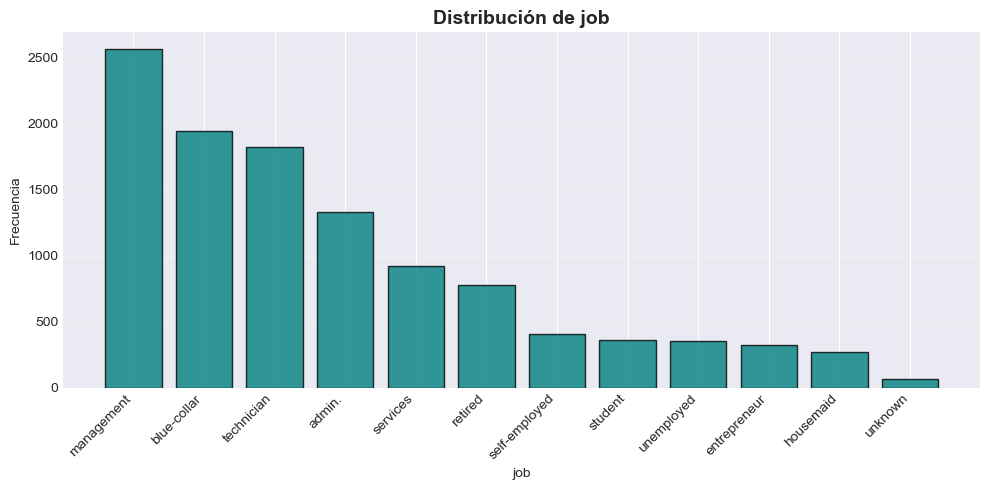


 TABLA DE FRECUENCIAS: MARITAL


,Categoría,Frecuencia,Porcentaje
0,married,6349,56.88
1,single,3517,31.51
2,divorced,1291,11.57


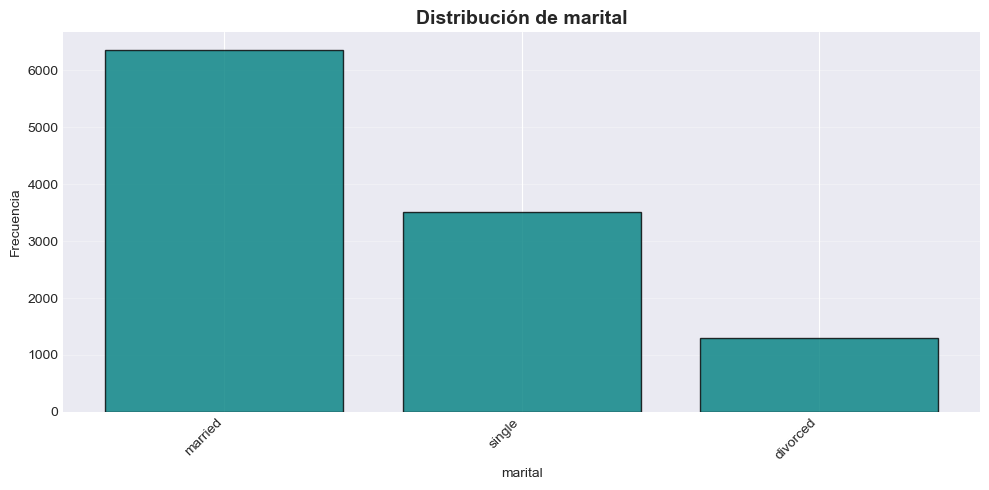


 TABLA DE FRECUENCIAS: EDUCATION


,Categoría,Frecuencia,Porcentaje
0,secondary,5474,49.04
1,tertiary,3685,33.01
2,primary,1500,13.44
3,unknown,496,4.44


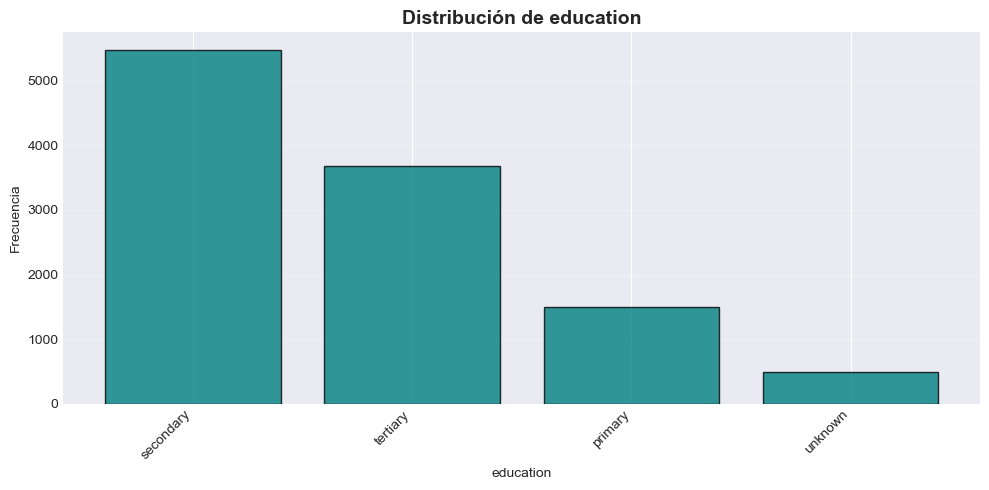


 TABLA DE FRECUENCIAS: DEFAULT


,Categoría,Frecuencia,Porcentaje
0,no,10994,98.49
1,yes,168,1.51


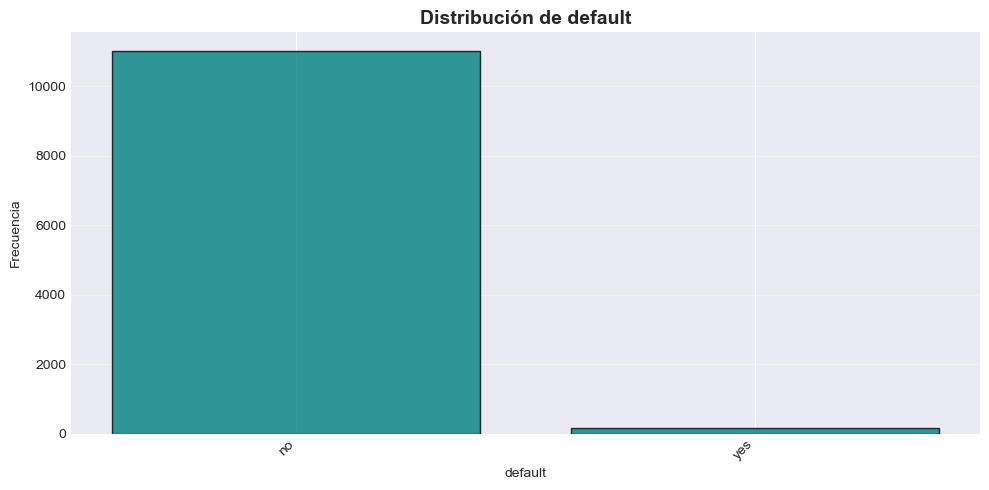


 TABLA DE FRECUENCIAS: HOUSING


,Categoría,Frecuencia,Porcentaje
0,no,5881,52.69
1,yes,5281,47.31


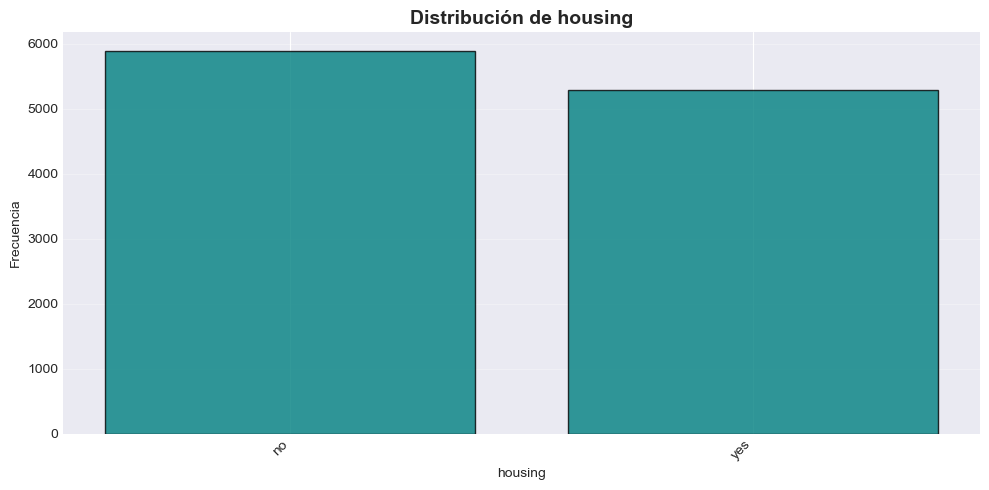


 TABLA DE FRECUENCIAS: LOAN


,Categoría,Frecuencia,Porcentaje
0,no,9702,86.92
1,yes,1460,13.08


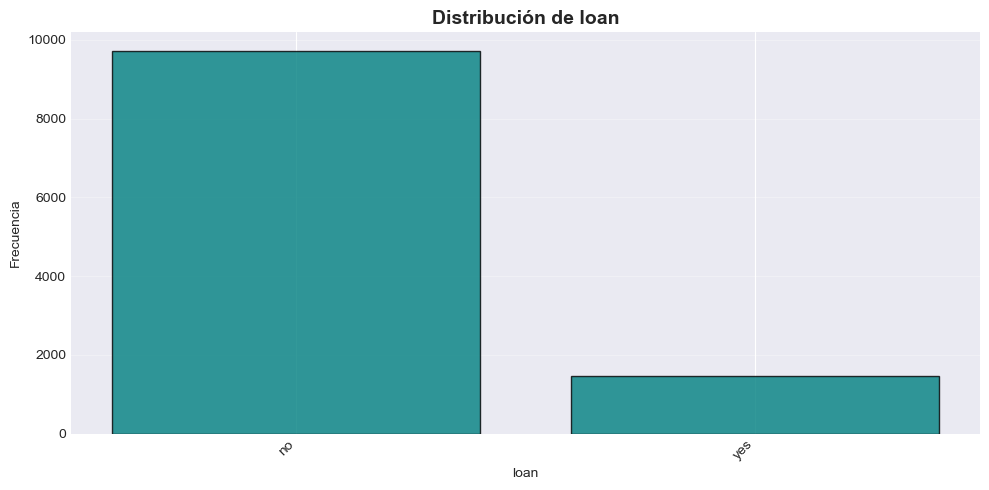


 TABLA DE FRECUENCIAS: CONTACT


,Categoría,Frecuencia,Porcentaje
0,cellular,8042,72.05
1,unknown,2346,21.02
2,telephone,774,6.93


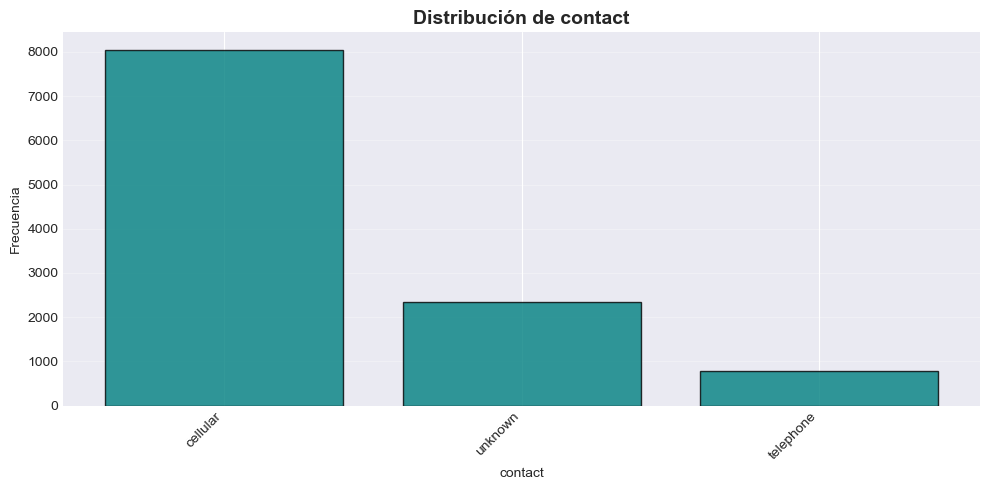


 TABLA DE FRECUENCIAS: MONTH


,Categoría,Frecuencia,Porcentaje
0,may,2824,25.30
1,aug,1519,13.61
2,jul,1514,13.56
3,jun,1222,10.95
4,nov,943,8.45
5,apr,923,8.27
6,feb,776,6.95
7,oct,392,3.51
8,jan,344,3.08
9,sep,319,2.86


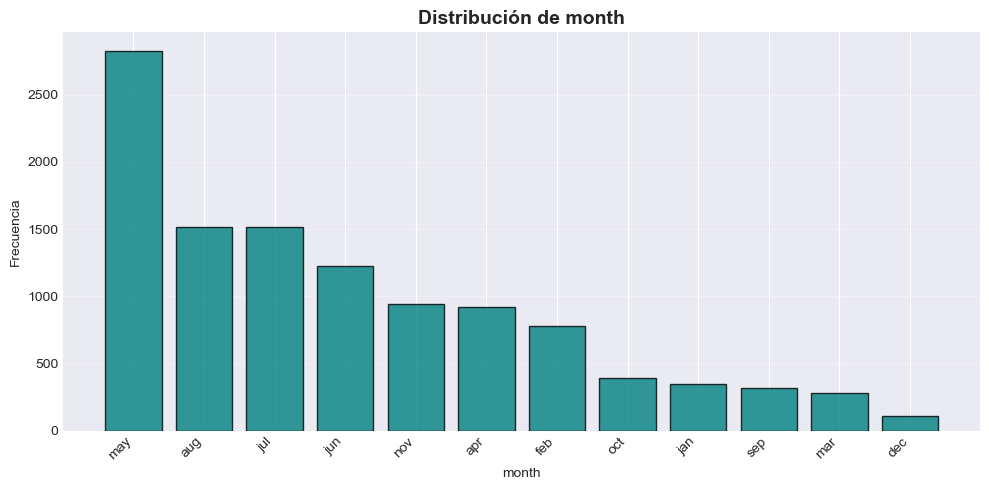


 TABLA DE FRECUENCIAS: POUTCOME


,Categoría,Frecuencia,Porcentaje
0,unknown,8326,74.59
1,failure,1228,11.00
2,success,1071,9.60
3,other,537,4.81


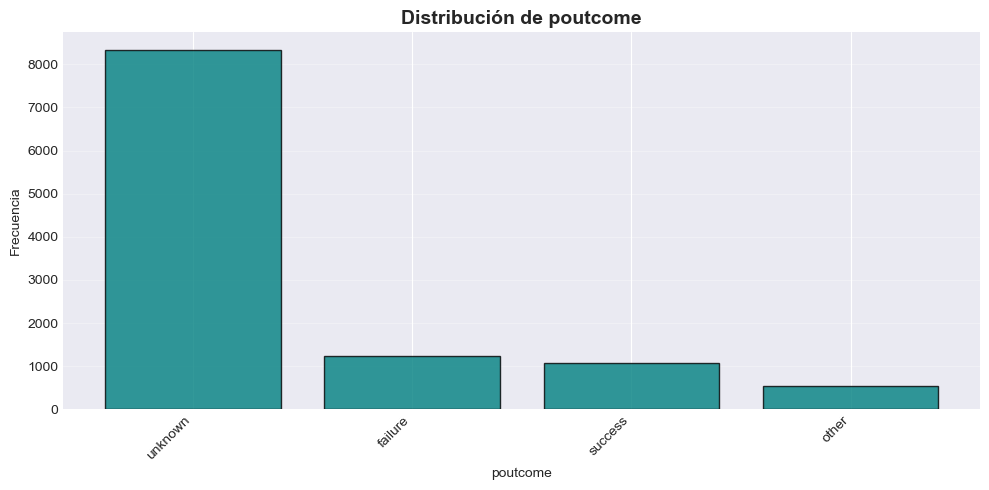


 TABLA DE FRECUENCIAS: DEPOSIT


,Categoría,Frecuencia,Porcentaje
0,no,5873,52.62
1,yes,5289,47.38


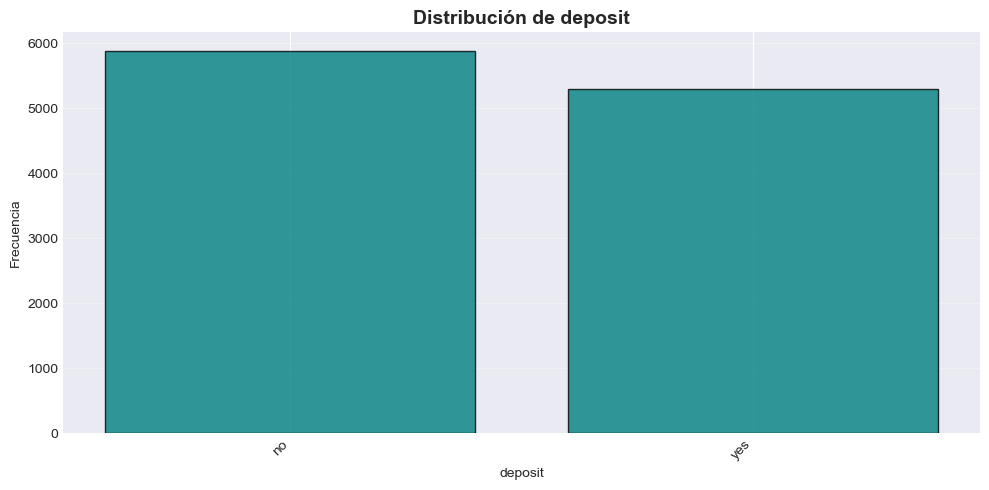

In [29]:
# 3. Tablas de frecuencias para cada variable categórica
for col in categorical_cols:
    freq_table = df[col].value_counts().reset_index()
    freq_table.columns = ['Categoría', 'Frecuencia']
    freq_table['Porcentaje'] = (freq_table['Frecuencia'] / len(df)) * 100
    
    print(f"\n TABLA DE FRECUENCIAS: {col.upper()}")
    display(freq_table)

    # Gráfico de barras
    plt.figure(figsize=(10, 5))
    plt.bar(freq_table['Categoría'], freq_table['Frecuencia'], color='teal', edgecolor='black', alpha=0.8)
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.title(f'Distribución de {col}', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    

- Perfil Laboral: El cargo más frecuente es management (2,566 clientes).  
- Estado Civil y Educación: La mayoría de los clientes están casados (married) y tienen un nivel educativo de secundaria (secondary).  
- Vivienda y Préstamos: Un alto porcentaje de clientes no tiene deudas de vivienda (housing: no) ni préstamos personales (loan: no).  
- Temporalidad: Mayo es el mes con mayor actividad de contacto (2,824 llamadas).  

Conclusión:
- El cliente típico de Banco Atlas es un profesional administrativo o de gestión, casado, con educación secundaria y libre de deudas personales inmediatas.
- Existe una concentración de las campañas en el mes de mayo.

### ANÁLISIS EXPLORATORIO BIVARIADO (Relaciones entre Variables) - DESAFÍO 3

#### 1. Preparación de Variables Compuestas para el Análisis

In [30]:
# Crear una copia 
df_bivariado = df.copy()

# Convertir variables binarias a numéricas (1: yes, 0: no) para sumar productos
# Productos: loan (préstamo), housing (hipoteca), deposit (depósito)
cols_productos = ['loan', 'housing', 'deposit']
for col in cols_productos:
    df_bivariado[f'{col}_num'] = df_bivariado[col].map({'yes': 1, 'no': 0})

# Calcular el total de productos por cliente
df_bivariado['total_productos'] = df_bivariado[['loan_num', 'housing_num', 'deposit_num']].sum(axis=1)

# Identificar clientes multi-producto (más de 1 producto)
df_bivariado['es_multiproducto'] = df_bivariado['total_productos'] > 1

#### 2. RELACIONES DEMOGRÁFICAS × PRODUCTOS FINANCIEROS
Exploración de cómo la ocupación y el nivel educativo se distribuyen según la cantidad de productos contratados.

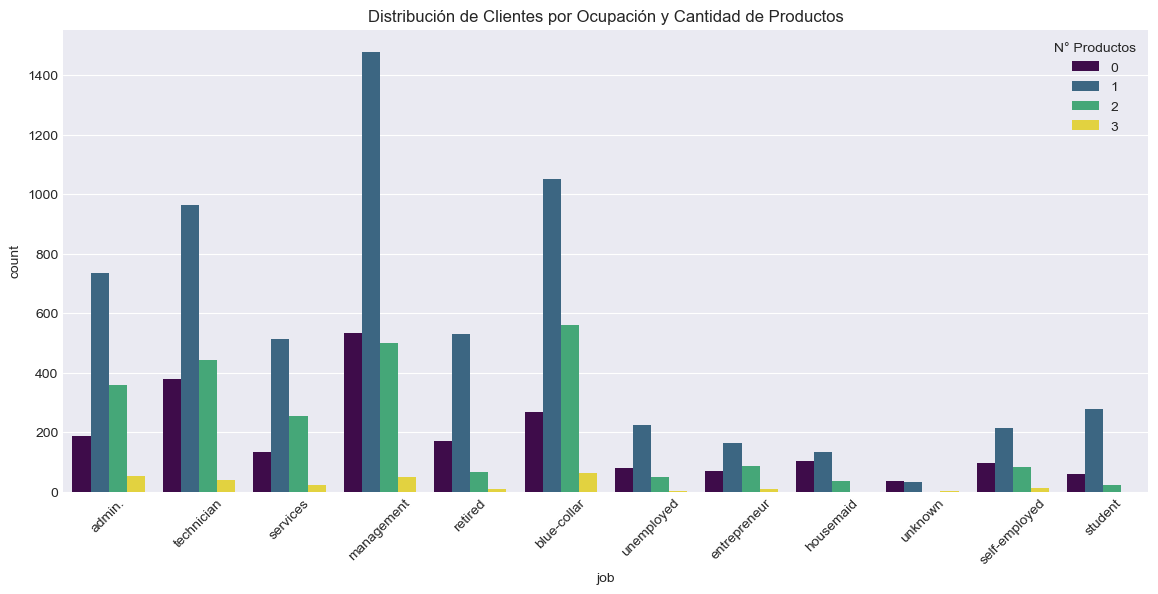

In [31]:
# 1. Relación Ocupación (job) vs Uso de Múltiples Productos
plt.figure(figsize=(14, 6))
sns.countplot(data=df_bivariado, x='job', hue='total_productos', palette='viridis')
plt.title('Distribución de Clientes por Ocupación y Cantidad de Productos')
plt.xticks(rotation=45)
plt.legend(title='N° Productos', loc='upper right')
plt.show()

In [32]:
# 2. Tabla de contingencia: Educación vs Cliente Multi-producto
edu_multi_table = pd.crosstab(df_bivariado['education'], df_bivariado['es_multiproducto'], normalize='index') * 100
print("Porcentaje de Clientes Multi-producto por Nivel Educativo:")
display(edu_multi_table)

Porcentaje de Clientes Multi-producto por Nivel Educativo:


es_multiproducto,False,True
education,,
primary,78.13,21.87
secondary,71.94,28.06
tertiary,78.67,21.33
unknown,85.28,14.72


C:\Users\Margot\AppData\Local\Temp\ipykernel_18412\2966838703.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bivariado, x='total_productos', y='age', palette='Set2')


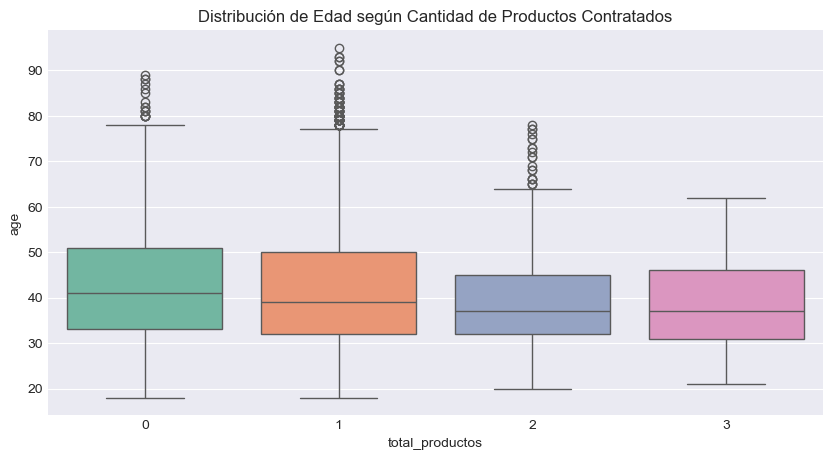

In [33]:
# 3. Edad vs Total de Productos (Boxplot)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_bivariado, x='total_productos', y='age', palette='Set2')
plt.title('Distribución de Edad según Cantidad de Productos Contratados')
plt.show()

**Conclusión:**
Se observa que los clientes con niveles de educación superior (tertiary) y cargos en management tienden a contratar el depósito con mayor frecuencia.

#### 3. RELACIONES TEMPORALES × EFECTIVIDAD DE CAMPAÑA
Análisis de la relación entre el momento del contacto (día del mes) y la contratación del depósito.

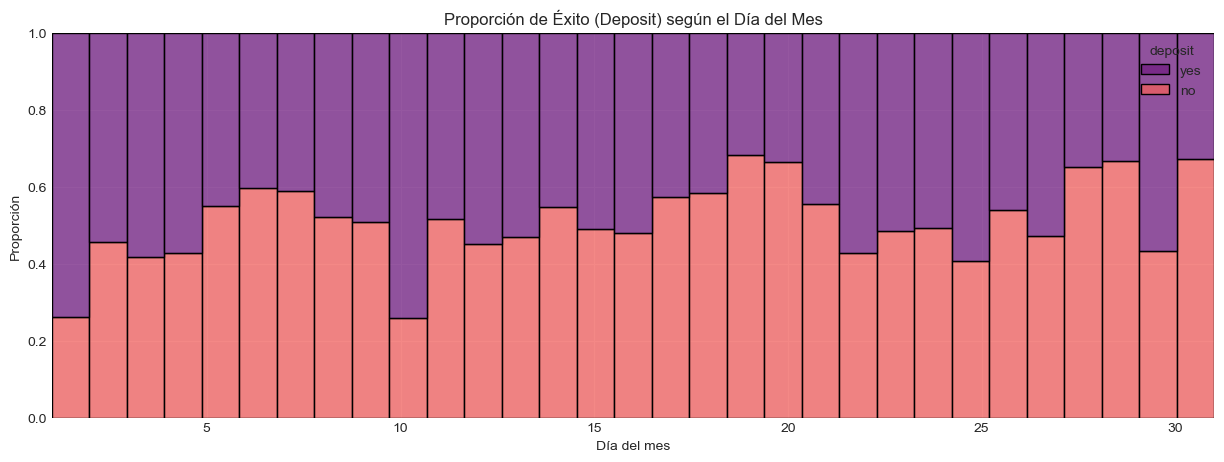

In [34]:
# 1. Día del mes vs Éxito del Depósito
plt.figure(figsize=(15, 5))
sns.histplot(data=df_bivariado, x='day', hue='deposit', multiple='fill', palette='magma', bins=31)
plt.title('Proporción de Éxito (Deposit) según el Día del Mes')
plt.xlabel('Día del mes')
plt.ylabel('Proporción')
plt.show()

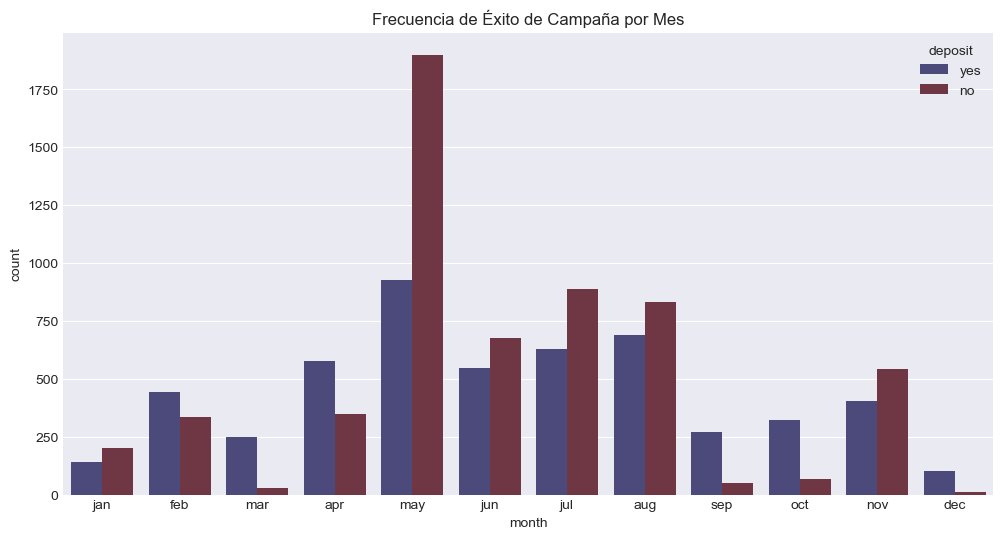

In [35]:
# 2. Mes vs Éxito del Depósito
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
plt.figure(figsize=(12, 6))
sns.countplot(data=df_bivariado, x='month', hue='deposit', order=month_order, palette='icefire')
plt.title('Frecuencia de Éxito de Campaña por Mes')
plt.show()

**Conclusión:**
La efectividad de la campaña varía según el día del mes (day); los contactos realizados a mitad de mes muestran picos de conversión distintos a los de fin de mes.

#### 4. RELACIONES BALANCE × RIESGO CREDITICIO
Exploración de la relación entre el saldo bancario (balance) y los indicadores de riesgo (default).

C:\Users\Margot\AppData\Local\Temp\ipykernel_18412\1454801974.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_bivariado, x='default', y='balance', jitter=True, alpha=0.5, palette='rocket')


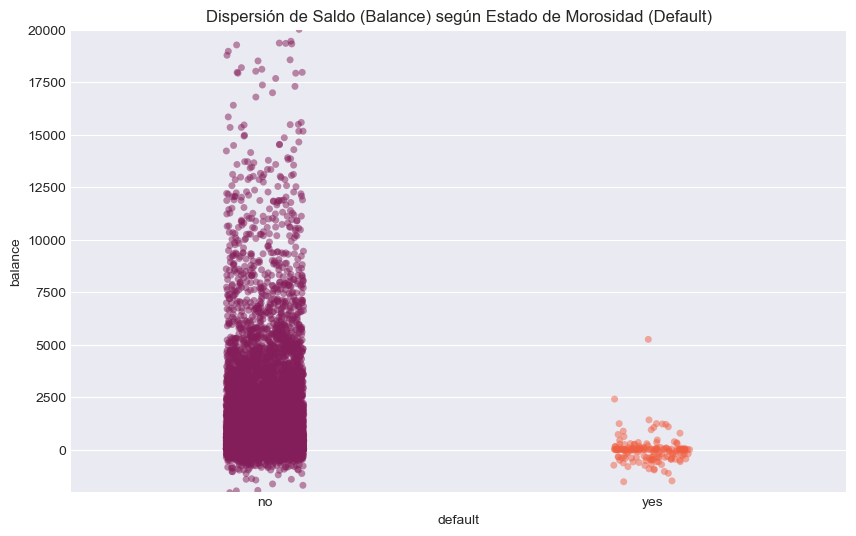

In [36]:
# 1. Balance vs Default (Riesgo de Morosidad)
plt.figure(figsize=(10, 6))
sns.stripplot(data=df_bivariado, x='default', y='balance', jitter=True, alpha=0.5, palette='rocket')
plt.title('Dispersión de Saldo (Balance) según Estado de Morosidad (Default)')
plt.ylim(-2000, 20000) # Limitamos eje Y para ver mejor la concentración
plt.show()

In [37]:
# 2. Estadísticos de Balance por categoría de Default
balance_risk_stats = df_bivariado.groupby('default')['balance'].agg(['mean', 'median', 'std', 'min', 'max'])
print("Estadísticos de Saldo (Balance) según Riesgo Crediticio:")
display(balance_risk_stats)

Estadísticos de Saldo (Balance) según Riesgo Crediticio:


,mean,median,std,min,max
default,,,,,
no,1552.84,564.50,3242.32,-3058,81204
yes,-61.80,0.00,827.74,-6847,5249


**Conclusión:**
Los clientes con balance negativo o cercano a cero muestran una tendencia casi nula a contratar depósitos y representan un mayor riesgo de morosidad (default).

**Conclusión General:**

- La estabilidad financiera (saldo positivo) se relaciona fuertemente con la conversión de productos.
- La estrategia de comunicación debe considerar el perfil demográfico: los jóvenes y jubilados responden de manera distinta a los profesionales activos.

### CORRELACIONES Y VISUALIZACIONES GENERALES

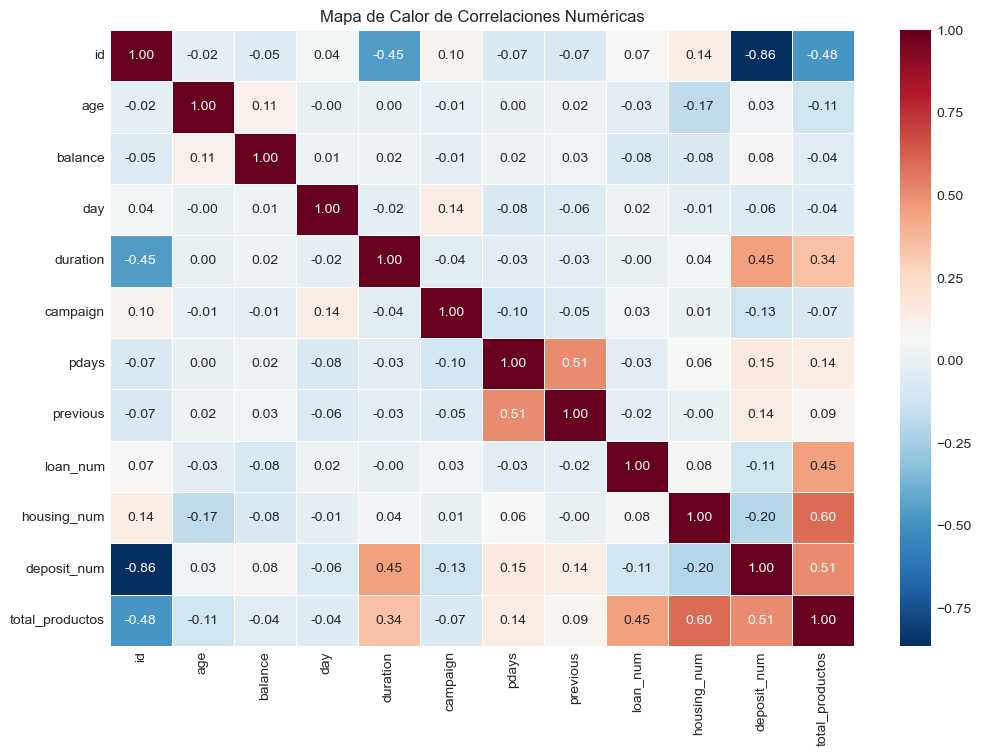

In [38]:
# Matriz de Correlación de variables numéricas
plt.figure(figsize=(12, 8))
corr_matrix = df_bivariado.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones Numéricas')
plt.show()

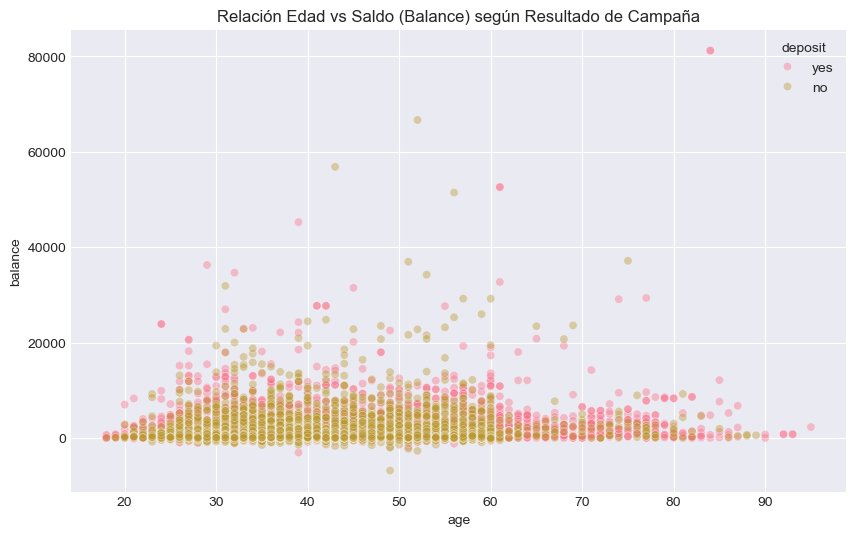

In [39]:
# Relación Balance vs Edad coloreado por Depósito
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_bivariado, x='age', y='balance', hue='deposit', alpha=0.4)
plt.title('Relación Edad vs Saldo (Balance) según Resultado de Campaña')
plt.show()

- Se identifica una correlación positiva moderada entre la duración de la llamada (duration) y el éxito de la operación (deposit). A mayor tiempo de conversación, mayor probabilidad de éxito.
- No se observan correlaciones lineales fuertes entre variables demográficas y financieras, lo que sugiere que el comportamiento del cliente es multicausal.

#### CONCLUSION

- El dataset presenta una estructura completa y buena calidad de datos, con escasos valores nulos y con una ausencia casi total de duplicados y un nivel de valores nulos inferior al 0.1%, lo que otorga una alta confiabilidad a las inferencias estadísticas presentadas. 
- El análisis revela que el cliente con mayor propensión a la contratación de depósitos es aquel con un perfil profesional de gestión (management), educación terciaria y una situación financiera estable, caracterizada por la ausencia de deudas de vivienda o préstamos personales.
- Existe una correlación positiva entre la duración de la llamada y la conversión, mientras que el contacto excesivo (más de 3-4 veces) no garantiza mejores resultados y puede saturar al cliente.
- Segmentación Financiera: El saldo (balance) actúa como un filtro de viabilidad; los registros con saldos negativos presentan una nula conversión y deben ser tratados bajo estrategias de recuperación o riesgo, no de captación de pasivos.
- Oportunidad Temporal: Mayo destaca como el mes de mayor actividad, siendo una oportunidad que debe ser aprovechada con ofertas personalizadas.

En conjunto, los datos permiten abordar análisis posteriores desde distintas perspectivas de negocio.